In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\Shambhavi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

pd.set_option('display.max_columns', None)

print("All libraries imported successfully!")


All libraries imported successfully!


In [6]:
import os
print(os.getcwd())

C:\Users\Shambhavi


In [7]:
df = pd.read_csv('matches.csv')

print(f"Rows (matches): {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows (matches): 1095
Columns: 20


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [8]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [9]:
# Remove matches where there is no winner (abandoned matches)
df = df.dropna(subset=['winner'])

# Remove no result matches
df = df[df['result'] != 'no result']

# Drop columns we don't need at all
df = df.drop(columns=['method', 'player_of_match', 'umpire1', 'umpire2', 'id'])

print(f"Matches after cleaning: {len(df)}")
print(f"Columns remaining: {df.shape[1]}")

Matches after cleaning: 1090
Columns remaining: 15


In [10]:
# Convert date column to proper date format
df['date'] = pd.to_datetime(df['date'])

# Sort by date — oldest match first
df = df.sort_values('date').reset_index(drop=True)

print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print("Data sorted chronologically!")

Date range: 2008-04-18 to 2024-05-26
Data sorted chronologically!


In [11]:
# Standardize team names
# Some teams changed names over the years
# We treat them as the same team throughout history

team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Kings XI Punjab': 'Punjab Kings',
}

for col in ['team1', 'team2', 'winner', 'toss_winner']:
    df[col] = df[col].replace(team_name_map)

print("Team names standardized!")
print(f"\nAll unique teams ({df['team1'].nunique()}):")
for team in sorted(df['team1'].unique()):
    print(f"  • {team}")

Team names standardized!

All unique teams (15):
  • Chennai Super Kings
  • Delhi Capitals
  • Gujarat Lions
  • Gujarat Titans
  • Kochi Tuskers Kerala
  • Kolkata Knight Riders
  • Lucknow Super Giants
  • Mumbai Indians
  • Pune Warriors
  • Punjab Kings
  • Rajasthan Royals
  • Rising Pune Supergiants
  • Royal Challengers Bangalore
  • Royal Challengers Bengaluru
  • Sunrisers Hyderabad


In [12]:
# Fix RCB name
rcb_fix = {
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

for col in ['team1', 'team2', 'winner', 'toss_winner']:
    df[col] = df[col].replace(rcb_fix)

print("Fixed!")
print(f"Total unique teams now: {df['team1'].nunique()}")
for team in sorted(df['team1'].unique()):
    print(f"  • {team}")
    

Fixed!
Total unique teams now: 14
  • Chennai Super Kings
  • Delhi Capitals
  • Gujarat Lions
  • Gujarat Titans
  • Kochi Tuskers Kerala
  • Kolkata Knight Riders
  • Lucknow Super Giants
  • Mumbai Indians
  • Pune Warriors
  • Punjab Kings
  • Rajasthan Royals
  • Rising Pune Supergiants
  • Royal Challengers Bengaluru
  • Sunrisers Hyderabad


In [13]:
def get_last_n_win_rate(df, team, match_index, n=5):
    past_matches = df[
        (df.index < match_index) &
        ((df['team1'] == team) | (df['team2'] == team))
    ].tail(n)
    
    if len(past_matches) == 0:
        return 0.5
    
    wins = (past_matches['winner'] == team).sum()
    return wins / len(past_matches)


def get_head_to_head_rate(df, team1, team2, match_index):
    past = df[
        (df.index < match_index) &
        (
            ((df['team1'] == team1) & (df['team2'] == team2)) |
            ((df['team1'] == team2) & (df['team2'] == team1))
        )
    ]
    
    if len(past) == 0:
        return 0.5
    
    wins = (past['winner'] == team1).sum()
    return wins / len(past)


print("Functions ready!")

Functions ready!


In [14]:
team1_win_rates = []
team2_win_rates = []
h2h_rates = []

for idx, row in df.iterrows():
    team1 = row['team1']
    team2 = row['team2']
    
    t1 = get_last_n_win_rate(df, team1, idx, n=5)
    t2 = get_last_n_win_rate(df, team2, idx, n=5)
    h2h = get_head_to_head_rate(df, team1, team2, idx)
    
    team1_win_rates.append(t1)
    team2_win_rates.append(t2)
    h2h_rates.append(h2h)

df['team1_last5_winrate'] = team1_win_rates
df['team2_last5_winrate'] = team2_win_rates
df['head_to_head_winrate'] = h2h_rates

print("Features calculated!")
df[['team1', 'team2', 'team1_last5_winrate', 'team2_last5_winrate', 'head_to_head_winrate', 'winner']].head(8)

Features calculated!


,team1,team2,team1_last5_winrate,team2_last5_winrate,head_to_head_winrate,winner
0,Royal Challengers Bengaluru,Kolkata Knight Riders,0.5,0.5,0.5,Kolkata Knight Riders
1,Punjab Kings,Chennai Super Kings,0.5,0.5,0.5,Chennai Super Kings
2,Delhi Capitals,Rajasthan Royals,0.5,0.5,0.5,Delhi Capitals
3,Mumbai Indians,Royal Challengers Bengaluru,0.5,0.0,0.5,Royal Challengers Bengaluru
4,Kolkata Knight Riders,Sunrisers Hyderabad,1.0,0.5,0.5,Kolkata Knight Riders
5,Rajasthan Royals,Punjab Kings,0.0,0.0,0.5,Rajasthan Royals
6,Sunrisers Hyderabad,Delhi Capitals,0.0,1.0,0.5,Delhi Capitals
7,Chennai Super Kings,Mumbai Indians,1.0,0.0,0.5,Chennai Super Kings


In [15]:
df[['team1', 'team2', 'team1_last5_winrate', 'team2_last5_winrate', 'head_to_head_winrate', 'winner']].head(8)

,team1,team2,team1_last5_winrate,team2_last5_winrate,head_to_head_winrate,winner
0,Royal Challengers Bengaluru,Kolkata Knight Riders,0.5,0.5,0.5,Kolkata Knight Riders
1,Punjab Kings,Chennai Super Kings,0.5,0.5,0.5,Chennai Super Kings
2,Delhi Capitals,Rajasthan Royals,0.5,0.5,0.5,Delhi Capitals
3,Mumbai Indians,Royal Challengers Bengaluru,0.5,0.0,0.5,Royal Challengers Bengaluru
4,Kolkata Knight Riders,Sunrisers Hyderabad,1.0,0.5,0.5,Kolkata Knight Riders
5,Rajasthan Royals,Punjab Kings,0.0,0.0,0.5,Rajasthan Royals
6,Sunrisers Hyderabad,Delhi Capitals,0.0,1.0,0.5,Delhi Capitals
7,Chennai Super Kings,Mumbai Indians,1.0,0.0,0.5,Chennai Super Kings


In [16]:
# Did team1 win the toss?
df['team1_won_toss'] = (df['toss_winner'] == df['team1']).astype(int)

# Toss decision encoded (bat=1, field=0)
df['toss_decision_encoded'] = (df['toss_decision'] == 'bat').astype(int)

# TARGET variable — what we want to predict
# 1 = team1 won, 0 = team2 won
df['team1_won'] = (df['winner'] == df['team1']).astype(int)

print("All features ready!")
print(f"\nTeam1 won: {df['team1_won'].sum()} matches")
print(f"Team2 won: {(1-df['team1_won']).sum()} matches")

All features ready!

Team1 won: 555 matches
Team2 won: 535 matches


In [17]:
feature_columns = [
    'team1_last5_winrate',
    'team2_last5_winrate',
    'head_to_head_winrate',
    'team1_won_toss',
    'toss_decision_encoded',
]

X = df[feature_columns]  # inputs
y = df['team1_won']      # output

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {len(X_train)} matches")
print(f"Testing set:  {len(X_test)} matches")

Training set: 872 matches
Testing set:  218 matches


In [18]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")

Logistic Regression Accuracy: 48.62%


In [19]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

Random Forest Accuracy: 48.17%


In [20]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)

print(f"Gradient Boosting Accuracy: {gb_acc*100:.2f}%")

Gradient Boosting Accuracy: 47.71%


In [21]:
# Instead of raw win rates, use the DIFFERENCE between teams
# Positive = team1 is in better form, Negative = team2 is in better form

df['form_difference'] = df['team1_last5_winrate'] - df['team2_last5_winrate']
df['h2h_advantage'] = df['head_to_head_winrate'] - 0.5

feature_columns = [
    'form_difference',
    'h2h_advantage',
    'team1_won_toss',
    'toss_decision_encoded',
]

X = df[feature_columns]
y = df['team1_won']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Retrain all 3 models
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr_model.predict(X_test))

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)
gb_acc = accuracy_score(y_test, gb_model.predict(X_test))

print(f"Logistic Regression: {lr_acc*100:.2f}%")
print(f"Random Forest:       {rf_acc*100:.2f}%")
print(f"Gradient Boosting:   {gb_acc*100:.2f}%")

Logistic Regression: 51.38%
Random Forest:       55.50%
Gradient Boosting:   51.38%


In [22]:
# Add more meaningful features
df['total_experience'] = df.groupby('team1').cumcount() + df.groupby('team2').cumcount()
df['toss_and_bat'] = ((df['team1_won_toss'] == 1) & (df['toss_decision_encoded'] == 1)).astype(int)
df['toss_and_field'] = ((df['team1_won_toss'] == 1) & (df['toss_decision_encoded'] == 0)).astype(int)

feature_columns = [
    'form_difference',
    'h2h_advantage',
    'team1_won_toss',
    'toss_decision_encoded',
    'toss_and_bat',
    'toss_and_field',
    'team1_last5_winrate',
    'team2_last5_winrate',
]

X = df[feature_columns]
y = df['team1_won']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

Random Forest Accuracy: 50.92%


In [23]:
feature_columns = [
    'form_difference',
    'h2h_advantage',
    'team1_won_toss',
    'toss_decision_encoded',
]

X = df[feature_columns]
y = df['team1_won']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Best Model Accuracy: {rf_acc*100:.2f}%")

Best Model Accuracy: 55.50%


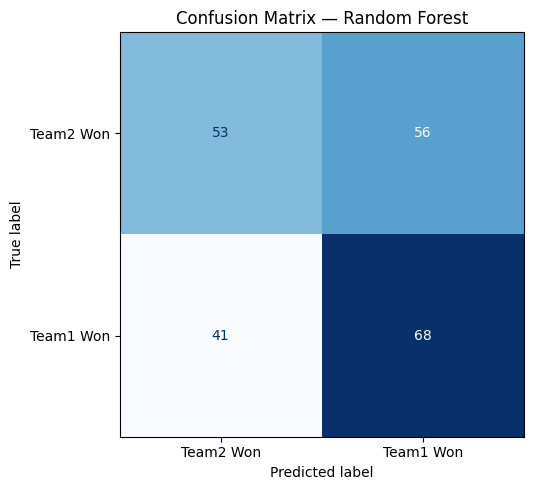

              precision    recall  f1-score   support

   Team2 Won       0.56      0.49      0.52       109
   Team1 Won       0.55      0.62      0.58       109

    accuracy                           0.56       218
   macro avg       0.56      0.56      0.55       218
weighted avg       0.56      0.56      0.55       218



In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Team2 Won', 'Team1 Won']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

print(classification_report(y_test, rf_pred,
      target_names=['Team2 Won', 'Team1 Won']))

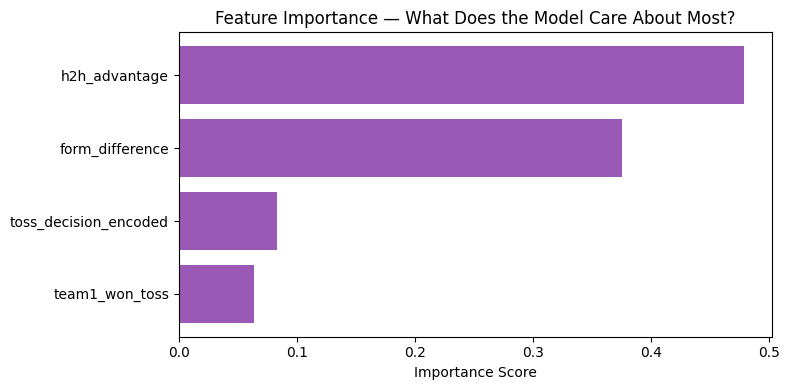

In [25]:
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#9b59b6')
plt.title('Feature Importance — What Does the Model Care About Most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [26]:
def predict_match(team1, team2,
                  team1_recent_winrate, team2_recent_winrate,
                  h2h_winrate, team1_won_toss, toss_decision='field'):

    form_diff = team1_recent_winrate - team2_recent_winrate
    h2h_adv = h2h_winrate - 0.5
    toss_dec_enc = 1 if toss_decision == 'bat' else 0

    input_data = pd.DataFrame([{
        'form_difference': form_diff,
        'h2h_advantage': h2h_adv,
        'team1_won_toss': team1_won_toss,
        'toss_decision_encoded': toss_dec_enc
    }])

    prediction = rf_model.predict(input_data)[0]
    proba = rf_model.predict_proba(input_data)[0]
    t1_prob = proba[1] * 100
    t2_prob = proba[0] * 100

    print(f"{'='*45}")
    print(f"  MATCH: {team1} vs {team2}")
    print(f"{'='*45}")
    print(f"  {team1} recent win rate:  {team1_recent_winrate*100:.0f}%")
    print(f"  {team2} recent win rate:  {team2_recent_winrate*100:.0f}%")
    print(f"  H2H win rate ({team1}): {h2h_winrate*100:.0f}%")
    print(f"{'─'*45}")
    print(f"  Win Probabilities:")
    print(f"    {team1}: {t1_prob:.1f}%")
    print(f"    {team2}: {t2_prob:.1f}%")
    print(f"{'─'*45}")
    winner = team1 if prediction == 1 else team2
    print(f"  PREDICTED WINNER: {winner}")
    print(f"{'='*45}")


# Try it!
predict_match(
    team1='Mumbai Indians',
    team2='Chennai Super Kings',
    team1_recent_winrate=0.60,
    team2_recent_winrate=0.80,
    h2h_winrate=0.45,
    team1_won_toss=0,
    toss_decision='field'
)

  MATCH: Mumbai Indians vs Chennai Super Kings
  Mumbai Indians recent win rate:  60%
  Chennai Super Kings recent win rate:  80%
  H2H win rate (Mumbai Indians): 45%
─────────────────────────────────────────────
  Win Probabilities:
    Mumbai Indians: 50.8%
    Chennai Super Kings: 49.2%
─────────────────────────────────────────────
  PREDICTED WINNER: Mumbai Indians


In [27]:
import joblib
joblib.dump(rf_model, 'ipl_winner_model.pkl')
print("Model saved!")

Model saved!


In [28]:
predict_match(
    team1='Royal Challengers Bengaluru',
    team2='Gujarat Titans',
    team1_recent_winrate=0.80,
    team2_recent_winrate=0.40,
    h2h_winrate=0.55,
    team1_won_toss=1,
    toss_decision='bat'
)

  MATCH: Royal Challengers Bengaluru vs Gujarat Titans
  Royal Challengers Bengaluru recent win rate:  80%
  Gujarat Titans recent win rate:  40%
  H2H win rate (Royal Challengers Bengaluru): 55%
─────────────────────────────────────────────
  Win Probabilities:
    Royal Challengers Bengaluru: 51.2%
    Gujarat Titans: 48.8%
─────────────────────────────────────────────
  PREDICTED WINNER: Royal Challengers Bengaluru


In [29]:
predict_match(
    team1='Kolkata Knight Riders',
    team2='Gujarat Titans',
    team1_recent_winrate=0.36,
    team2_recent_winrate=0.67,
    h2h_winrate=0.17,
    team1_won_toss=0,
    toss_decision='bowl'
)

  MATCH: Kolkata Knight Riders vs Gujarat Titans
  Kolkata Knight Riders recent win rate:  36%
  Gujarat Titans recent win rate:  67%
  H2H win rate (Kolkata Knight Riders): 17%
─────────────────────────────────────────────
  Win Probabilities:
    Kolkata Knight Riders: 46.6%
    Gujarat Titans: 53.4%
─────────────────────────────────────────────
  PREDICTED WINNER: Gujarat Titans


In [30]:
predict_match(
    team1='Kolkata Knight Riders',
    team2='Gujarat Titans',
    team1_recent_winrate=0.80,
    team2_recent_winrate=1.00,
    h2h_winrate=0.33,
    team1_won_toss=0,
    toss_decision='bowl'
)

  MATCH: Kolkata Knight Riders vs Gujarat Titans
  Kolkata Knight Riders recent win rate:  80%
  Gujarat Titans recent win rate:  100%
  H2H win rate (Kolkata Knight Riders): 33%
─────────────────────────────────────────────
  Win Probabilities:
    Kolkata Knight Riders: 51.7%
    Gujarat Titans: 48.3%
─────────────────────────────────────────────
  PREDICTED WINNER: Kolkata Knight Riders


In [35]:
predict_match(
    team1='Royal Challengers Bengaluru',
    team2='Punjab Kings',
    team1_recent_winrate=0.60,
    team2_recent_winrate=0.00,
    h2h_winrate=0.51,
    team1_won_toss=1,
    toss_decision='bowl'
)

  MATCH: Royal Challengers Bengaluru vs Punjab Kings
  Royal Challengers Bengaluru recent win rate:  60%
  Punjab Kings recent win rate:  0%
  H2H win rate (Royal Challengers Bengaluru): 51%
─────────────────────────────────────────────
  Win Probabilities:
    Royal Challengers Bengaluru: 53.4%
    Punjab Kings: 46.6%
─────────────────────────────────────────────
  PREDICTED WINNER: Royal Challengers Bengaluru
